In [180]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/06_linear-regression-example.ipynb 06_linear-regression-example.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/06_linear-regression-example.ipynb 06_linear-regression-example.ipynb

[NbConvertApp] Converting notebook 06_linear-regression-example.ipynb to notebook
[NbConvertApp] Writing 98787 bytes to ../exercises/06_linear-regression-example.ipynb
[NbConvertApp] Converting notebook 06_linear-regression-example.ipynb to notebook
[NbConvertApp] Writing 124898 bytes to ../solutions/06_linear-regression-example.ipynb


In [181]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns
import sklearn

# Problem presentation
We want to determine the surface temperature based on a list of different environmental variables.

# STEP 01 PREPROCESSING DATA
The data is loaded with pandas, a library allowing to extract data from csv table files.


## Load data from file
The numpy array are provided in X_data and y_data variables

In [182]:
df = xr.open_dataset('../../projects/RiverStreamflow/data/61X13X0.nc',).to_dataframe().dropna().loc['2012':]

In [183]:
X_data = df[['air_pressure_at_sea_level',
             'low_type_cloud_area_fraction',
             'relative_humidity_2m',
             'surface_net_longwave_radiation', 
             'surface_net_shortwave_radiation',
             'precipitation_amount_hourly',
             'wind_direction', 
             'wind_speed', 
             'medium_type_cloud_area_fraction']].values
y_data = df['air_temperature_2m'].values

## Reshape data


In [184]:
X = ...
y = ...

In [185]:
print(X_data.shape)
print(y_data.shape)

X = X_data
y = y_data.reshape(-1,1)

print(y.shape)

(112686, 9)
(112686,)
(112686, 1)


## Split data into train and test data.
We ignore the validation dataset in that case


In [186]:
X_train, X_test, y_train, y_test = ...

TypeError: cannot unpack non-iterable ellipsis object

In [187]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, train_size=0.7, shuffle=True)

## Transform the data
This is not needed for decision tree, but we can still practice

In [188]:
scaler_X = ...
...
X_train_rescaled = ...
X_test_rescaled = ...

tranform_y = ...
...
y_train_rescaled = ...
y_test_rescaled = ...

In [189]:
scaler_X = sklearn.preprocessing.StandardScaler()
scaler_X.fit(X_train)
X_train_rescaled = scaler_X.transform(X_train)
X_test_rescaled = scaler_X.transform(X_test)

tranform_y = sklearn.preprocessing.StandardScaler()
tranform_y.fit(y_train)
y_train_rescaled = tranform_y.transform(y_train)
y_test_rescaled = tranform_y.transform(y_test)

# STEP 2: Define ML model and fit it to the data


In [190]:
from sklearn.linear_model import LinearRegression

## Create model

In [191]:
model = ...

In [192]:
model = LinearRegression()

In [193]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Fit the model to the data

In [194]:
...

Ellipsis

In [195]:
model.fit(X_train_rescaled, y_train_rescaled[:,0])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# STEP 3: Evaluate the model skill


## Predict the results for the test data
And retrieve perdictions in the original data form by using the inverse_transform

In [196]:
predictions_test = ...
predictions_test_inverse_transform = ...

In [197]:
predictions_test = model.predict(X_test_rescaled)
predictions_test_inverse_transform = tranform_y.inverse_transform(predictions_test.reshape(-1,1))

## Plot the results

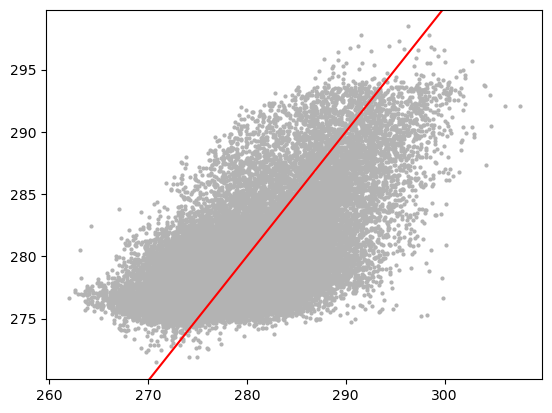

In [198]:
fig, ax = plt.subplots()

ax.scatter(x=y_test, y=predictions_test_inverse_transform, color='.7', s=4)
ax.axline((y_test.mean(),y_test.mean()), slope = 1, color='red')

## Evaluate the results with `r2_score` and `r2_score`

In [199]:
r2_score = ...
rmse = ...

In [200]:
r2_score = sklearn.metrics.r2_score(y_test_rescaled, predictions_test)
rmse = sklearn.metrics.root_mean_squared_error(y_test_rescaled, predictions_test)

print(f"R2 score: {r2_score:.02f}")
print()
print(f"RMSE: {rmse:.02f}")

R2 score: 0.37

RMSE: 0.80


In [223]:
fit.coef_


array([-2.50223549])

In [225]:
fit = LinearRegression().fit(df[['surface_net_shortwave_radiation']],df['surface_net_longwave_radiation'])

Text(0.5, 0, 'Surface net shortwave radiation (W/m2)')

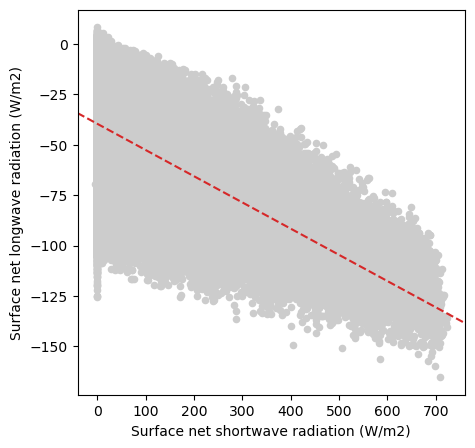

In [231]:
fig, ax =plt.subplots(figsize=(5,5))
df.plot.scatter(y='surface_net_longwave_radiation', x='surface_net_shortwave_radiation', ax=ax, color='.8')
ax.axline((0,fit.intercept_), slope=fit.coef_[0], color='tab:red', ls='--')
plt.ylabel('Surface net longwave radiation (W/m2)')
plt.xlabel('Surface net shortwave radiation (W/m2)')

In [233]:
fit.coef_

array([-0.13006622])